# FAKE REVIEW DETECTION USING MACHINE LEARNING


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Upload Dataset

In [8]:
df=pd.read_csv('/content/fake reviews dataset.csv', on_bad_lines='skip', encoding='latin1')
df

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...
...,...,...,...,...
40427,Clothing_Shoes_and_Jewelry_5,4.0,OR,I had read some reviews saying that this bra r...
40428,Clothing_Shoes_and_Jewelry_5,5.0,CG,I wasn't sure exactly what it would be. It is ...
40429,Clothing_Shoes_and_Jewelry_5,2.0,OR,"You can wear the hood by itself, wear it with ..."
40430,Clothing_Shoes_and_Jewelry_5,1.0,CG,I liked nothing about this dress. The only rea...


In [9]:
print("Dataset Loaded Successfully!")
print("Shape:", df.shape)

df.head()

Dataset Loaded Successfully!
Shape: (40432, 4)


,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


#Check Dataset Information

In [10]:
print("Columns:")
print(df.columns)

print("\nDataset Information:")
df.info()

Columns:
Index(['category', 'rating', 'label', 'text_'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  40432 non-null  object 
 1   rating    40432 non-null  float64
 2   label     40432 non-null  object 
 3   text_     40432 non-null  object 
dtypes: float64(1), object(3)
memory usage: 1.2+ MB


#Check Missing Values

In [11]:
print(df.isnull().sum())

category    0
rating      0
label       0
text_       0
dtype: int64


In [12]:
df = df.dropna(subset=["text_", "label"])

print("Dataset after removing missing values:")
print(df.shape)

Dataset after removing missing values:
(40432, 4)


#📊 Chart 1: Fake vs Original Reviews Pie Chart

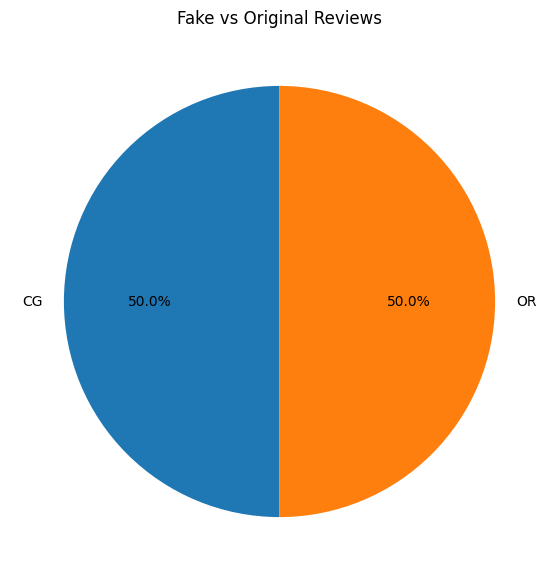

In [13]:
label_counts = df["label"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    label_counts.values,
    labels=label_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Fake vs Original Reviews")

plt.show()

#📊 Chart 2: Fake vs Original Bar Chart

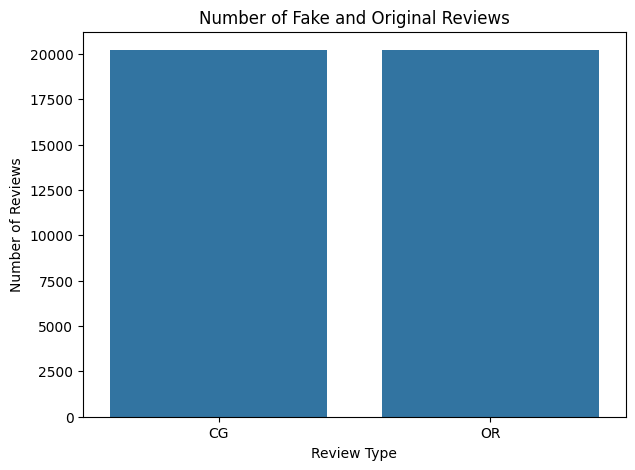

In [14]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="label"
)

plt.title("Number of Fake and Original Reviews")
plt.xlabel("Review Type")
plt.ylabel("Number of Reviews")

plt.show()

#📊 Chart 3: Rating Distribution Bar Chart

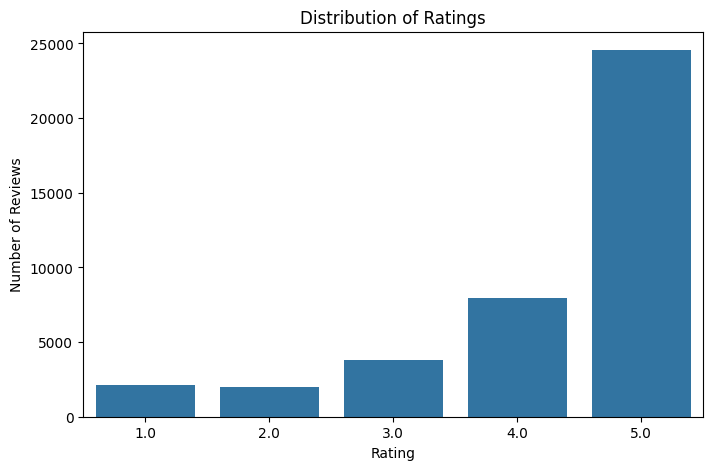

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="rating"
)

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.show()

#📊 Chart 4: Rating Histogram

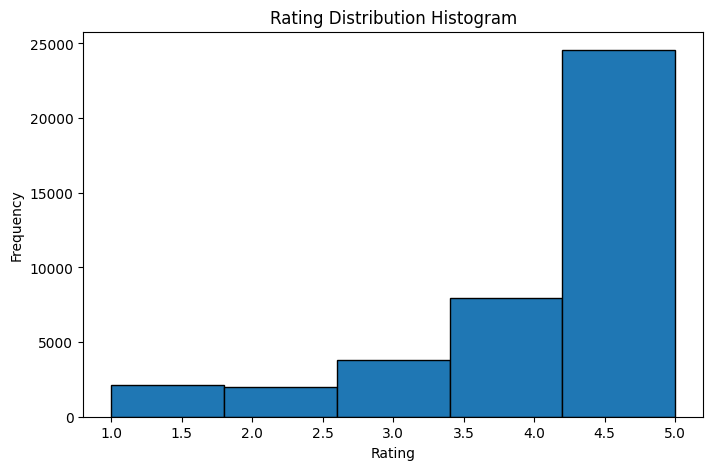

In [16]:
plt.figure(figsize=(8,5))

plt.hist(
    df["rating"],
    bins=5,
    edgecolor="black"
)

plt.title("Rating Distribution Histogram")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

#📊 Chart 5: Rating vs Review Type

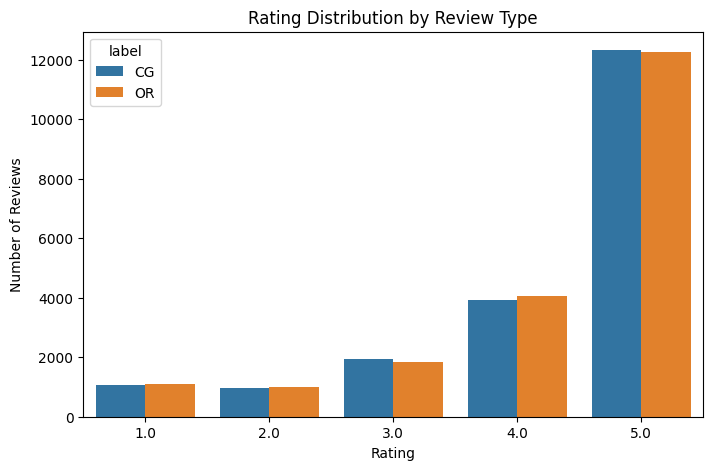

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="rating",
    hue="label"
)

plt.title("Rating Distribution by Review Type")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.show()

#📊 Chart 6: Category Distribution

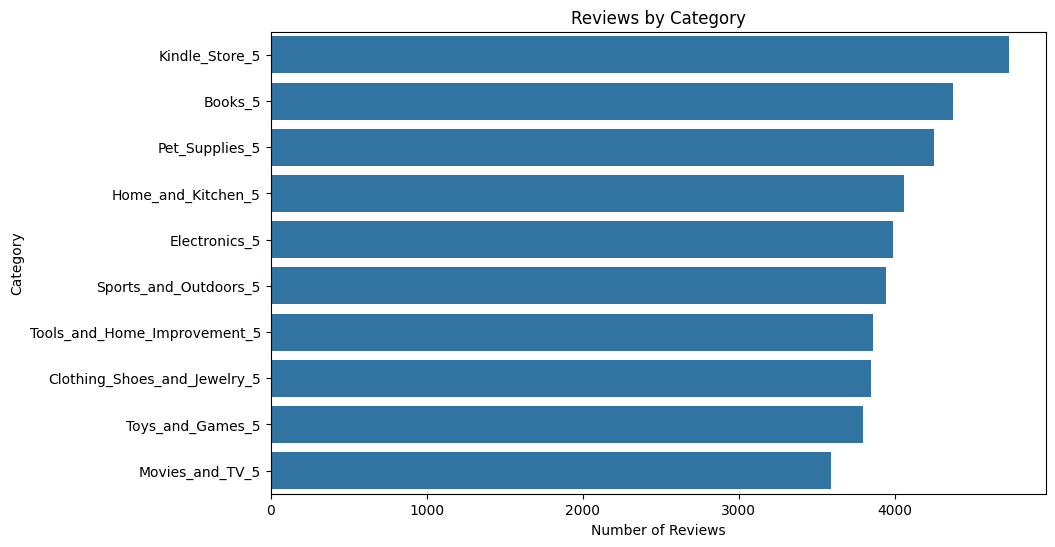

In [18]:
plt.figure(figsize=(10,6))

category_counts = df["category"].value_counts()

sns.barplot(
    x=category_counts.values,
    y=category_counts.index
)

plt.title("Reviews by Category")
plt.xlabel("Number of Reviews")
plt.ylabel("Category")

plt.show()

#📊 Chart 7: Review Length

In [19]:
df["review_length"] = df["text_"].astype(str).apply(len)

df[["text_", "review_length"]].head()

,text_,review_length
0,"Love this! Well made, sturdy, and very comfor...",75
1,"love it, a great upgrade from the original. I...",80
2,This pillow saved my back. I love the look and...,67
3,"Missing information on how to use it, but it i...",81
4,Very nice set. Good quality. We have had the s...,85


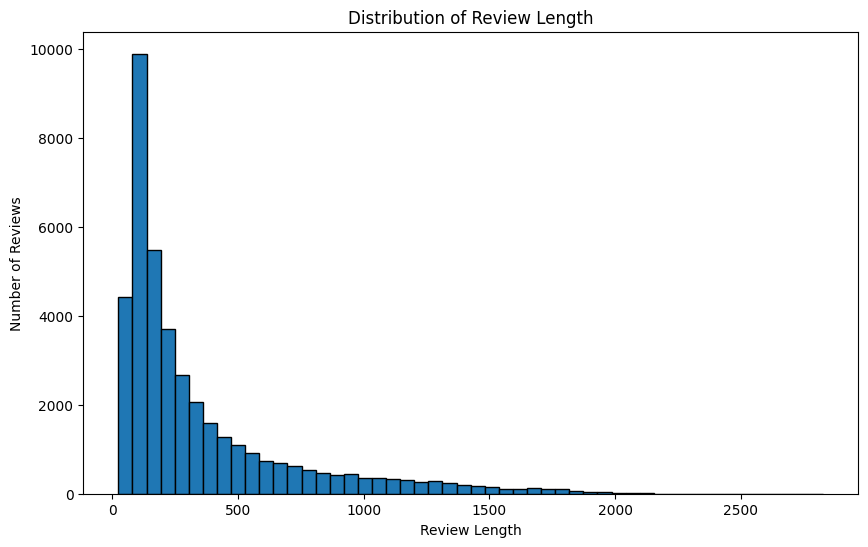

In [20]:
plt.figure(figsize=(10,6))

plt.hist(
    df["review_length"],
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of Review Length")
plt.xlabel("Review Length")
plt.ylabel("Number of Reviews")

plt.show()

#📊 Chart 8: Fake vs Original Review Length

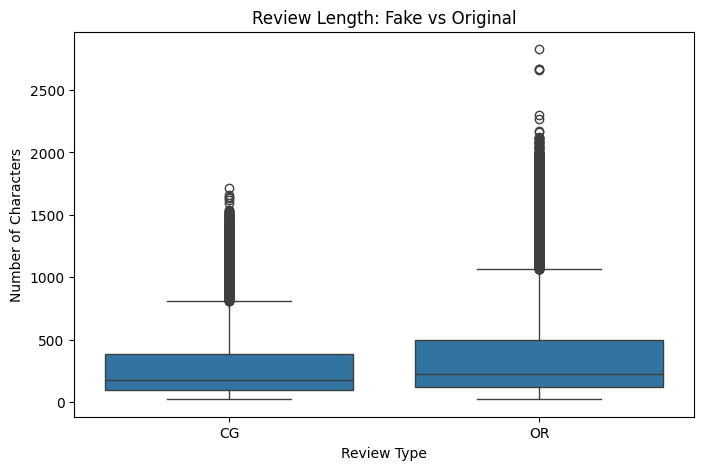

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="label",
    y="review_length"
)

plt.title("Review Length: Fake vs Original")
plt.xlabel("Review Type")
plt.ylabel("Number of Characters")

plt.show()

#📊 Chart 9: Average Rating by Review Type

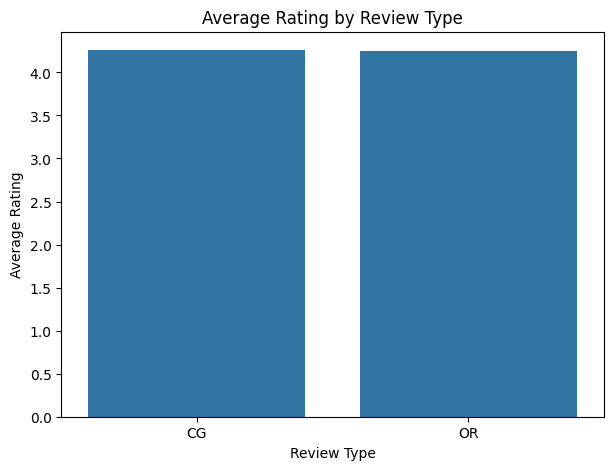

In [22]:
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df["rating"] = df["rating"].fillna(0)

average_rating = df.groupby("label")["rating"].mean()

plt.figure(figsize=(7,5))

sns.barplot(
    x=average_rating.index,
    y=average_rating.values
)

plt.title("Average Rating by Review Type")
plt.xlabel("Review Type")
plt.ylabel("Average Rating")

plt.show()

#📊 Chart 10: Correlation Heatmap

In [23]:
numeric_data = df[[
    "rating",
    "review_length"
]]

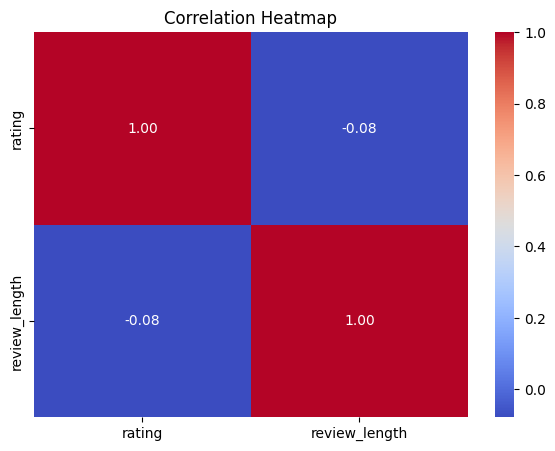

In [24]:
correlation = numeric_data.corr()

plt.figure(figsize=(7,5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

#🤖 Machine Learning Model

#Prepare Data

In [25]:
X = df["text_"]
y = df["label"]

print("Input Feature: text_")
print("Target Variable: label")

Input Feature: text_
Target Variable: label


#Check Target Labels

In [26]:
print(df["label"].value_counts())

label
CG    20216
OR    20216
Name: count, dtype: int64


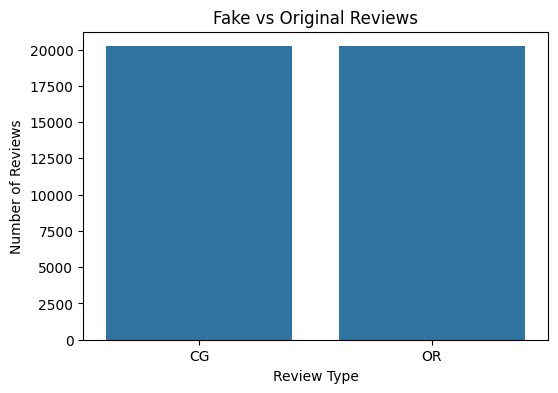

In [27]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="label")

plt.title("Fake vs Original Reviews")
plt.xlabel("Review Type")
plt.ylabel("Number of Reviews")

plt.show()

#Prepare Input and Output

In [28]:
X = df["text_"]
y = df["label"]

print("Input:")
print(X.head())

print("\nOutput:")
print(y.head())

Input:
0    Love this!  Well made, sturdy, and very comfor...
1    love it, a great upgrade from the original.  I...
2    This pillow saved my back. I love the look and...
3    Missing information on how to use it, but it i...
4    Very nice set. Good quality. We have had the s...
Name: text_, dtype: object

Output:
0    CG
1    CG
2    CG
3    CG
4    CG
Name: label, dtype: object


#Train-Test Split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 32345
Testing Samples: 8087


#TF-IDF

In [30]:
X = df["text_"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=10000
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF conversion completed!")

print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

TF-IDF conversion completed!
Training shape: (32345, 10000)
Testing shape: (8087, 10000)


#Train Logistic Regression

In [31]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train_tfidf,
    y_train
)

print("Model training completed!")

Model training completed!


#Convert Text into Numbers

In [32]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=10000
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF Shape:", X_train_tfidf.shape)
print("Testing TF-IDF Shape:", X_test_tfidf.shape)

Training TF-IDF Shape: (32345, 10000)
Testing TF-IDF Shape: (8087, 10000)


#Make Predictions

In [33]:
y_pred = model.predict(X_test_tfidf)

print("Predictions:")
print(y_pred[:20])

Predictions:
['OR' 'CG' 'OR' 'CG' 'OR' 'OR' 'CG' 'OR' 'OR' 'CG' 'CG' 'OR' 'CG' 'CG'
 'OR' 'OR' 'OR' 'OR' 'OR' 'CG']


#Check Accuracy

In [34]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Model Accuracy: 0.8641028811673056
Accuracy Percentage: 86.41028811673056 %


#Classification Report

In [35]:
import pandas as pd
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Load the dataset to define df
df = pd.read_csv('/content/fake reviews dataset.csv', on_bad_lines='skip', encoding='latin1')

# Re-define X and y
X = df["text_"]
y = df["label"]

# Re-perform train-test split to get y_test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Re-initialize and re-fit TF-IDF to get X_train_tfidf and X_test_tfidf
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=10000
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Re-initialize and re-train model to ensure it's available
model = LogisticRegression(
    max_iter=1000
)
model.fit(
    X_train_tfidf,
    y_train
)

# Re-make predictions to get y_pred
y_pred = model.predict(X_test_tfidf)

# Original code
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          CG       0.87      0.85      0.86      4044
          OR       0.86      0.88      0.87      4043

    accuracy                           0.86      8087
   macro avg       0.86      0.86      0.86      8087
weighted avg       0.86      0.86      0.86      8087



#Confusion Matrix

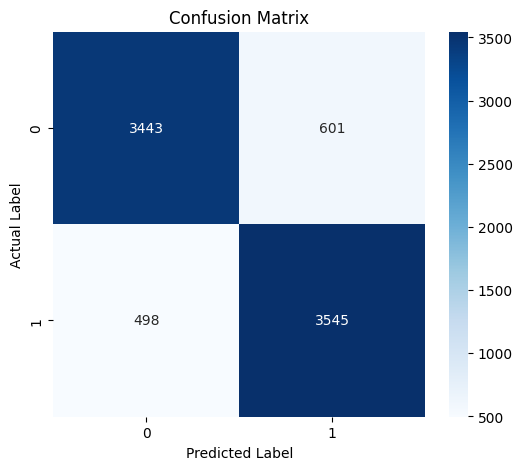

In [36]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

#Prediction

In [37]:
y_pred = model.predict(X_test_tfidf)

print("Prediction completed!")

Prediction completed!


#📊 Chart 11: Model Accuracy

In [38]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 86.41 %


#📊 Chart 12: Confusion Matrix Heatmap

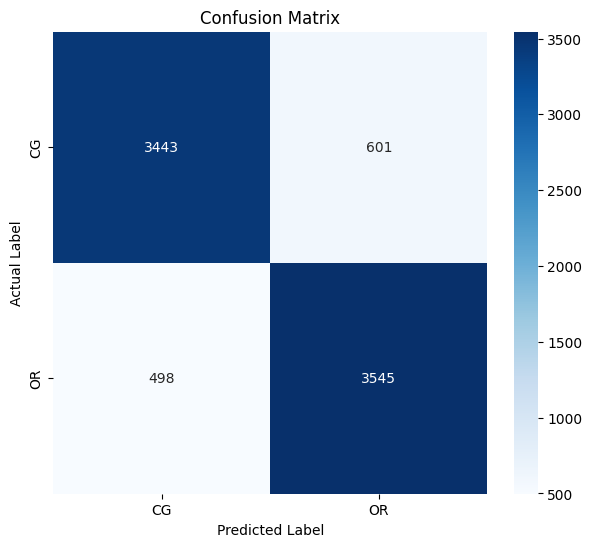

In [39]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

#📊 Chart 13: Classification Report

In [40]:
print("Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

Classification Report:

              precision    recall  f1-score   support

          CG       0.87      0.85      0.86      4044
          OR       0.86      0.88      0.87      4043

    accuracy                           0.86      8087
   macro avg       0.86      0.86      0.86      8087
weighted avg       0.86      0.86      0.86      8087



#⭐ Create Your Own Review Prediction

In [41]:
def predict_review(review):

    review_tfidf = tfidf.transform([review])

    prediction = model.predict(review_tfidf)[0]

    if prediction == "CG":
        result = "FAKE / COMPUTER GENERATED REVIEW"
    else:
        result = "ORIGINAL REVIEW"

    return result

#Test the Model

In [42]:
review = input("Enter a product review: ")

result = predict_review(review)

print("\nPrediction:", result)

Enter a product review: 2

Prediction: ORIGINAL REVIEW


#Test Multiple Reviews

In [43]:
reviews = [
    "This product is excellent and works exactly as described.",
    "Amazing amazing amazing! Best product ever! Everyone must buy this!",
    "The product arrived on time and the quality is good."
]

for review in reviews:
    print("Review:", review)
    print("Prediction:", predict_review(review))
    print("-" * 60)

Review: This product is excellent and works exactly as described.
Prediction: ORIGINAL REVIEW
------------------------------------------------------------
Review: Amazing amazing amazing! Best product ever! Everyone must buy this!
Prediction: ORIGINAL REVIEW
------------------------------------------------------------
Review: The product arrived on time and the quality is good.
Prediction: FAKE / COMPUTER GENERATED REVIEW
------------------------------------------------------------


#Show Prediction Probability

In [44]:
def predict_review_with_probability(review):

    review_tfidf = tfidf.transform([review])

    prediction = model.predict(review_tfidf)[0]

    probabilities = model.predict_proba(review_tfidf)[0]

    classes = model.classes_

    probability_dict = dict(zip(classes, probabilities))

    if prediction == "CG":
        result = "FAKE / COMPUTER GENERATED REVIEW"
    else:
        result = "ORIGINAL REVIEW"

    print("Review:")
    print(review)

    print("\nPrediction:", result)

    print("\nPrediction Probability:")

    for label, probability in probability_dict.items():
        print(label, ":", round(probability * 100, 2), "%")

#Save the Model

In [45]:
import joblib

joblib.dump(model, "fake_review_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model saved successfully!")

Model saved successfully!


In [46]:
import joblib

joblib.dump(
    model,
    "fake_review_model.pkl"
)

joblib.dump(
    tfidf,
    "tfidf_vectorizer.pkl"
)

print("Model saved successfully!")

Model saved successfully!


#Download Model Files

In [47]:
from google.colab import files

files.download("fake_review_model.pkl")
files.download("tfidf_vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>